# Stage 3 — Pipeline Evaluation & Validation

Val set'te top-K grid search + threshold calibration yapılır,  
ardından aynı threshold test setine uygulanarak final metrikler hesaplanır.

**Outputs:** `artifacts/threshold.json`, `outputs/val_*`, `outputs/test_*`

In [1]:
import os, sys, json
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm import tqdm
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, roc_auc_score,
    roc_curve, balanced_accuracy_score
)

PROJECT_ROOT = "/home/yasemin/video-anomaly-clip"
sys.path.append(PROJECT_ROOT)

from src.inference import CLIPInference
from src.aggregation import aggregate_video_scores
from src.config import ANOMALY_CLASSES, NORMAL_CLASSES

## Config

In [2]:
DATA_ROOT     = Path(PROJECT_ROOT) / "data"
MANIFEST_PATH = DATA_ROOT / "manifests_new" / "manifest.csv"
SEGMENTS_ROOT = DATA_ROOT / "segments_new"

# Initial placeholder — overwritten by top-K grid search (cell 8)
TOPK_RATIO  = 0.10
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

os.makedirs(f"{PROJECT_ROOT}/artifacts", exist_ok=True)
os.makedirs(f"{PROJECT_ROOT}/outputs",   exist_ok=True)

print("Config OK")

Config OK


## Load Manifest

In [3]:
df = pd.read_csv(MANIFEST_PATH)

# Manifest was generated on Colab; remap segment paths to local filesystem
df["path"] = df["path"].str.replace(
    "/content/drive/MyDrive/clip_delivery_new/segments",
    str(SEGMENTS_ROOT),
    regex=False
)

print(f"Manifest: {len(df)} rows")
print(df.columns.tolist())
print(df.head(3))
print("\nSplit distribution:")
print(df.groupby(["split", "label"]).size())

# Sanity check: paths must exist on disk
for p in df["path"].head(3):
    print(f"  {p} -> {Path(p).exists()}")

Manifest: 2180 rows
['segment_id', 'video_id', 'class', 'label', 'split', 'path']
  segment_id          video_id     class  label split  \
0   seg_0000  Stealing035_x264  Stealing      1   val   
1   seg_0001  Stealing035_x264  Stealing      1   val   
2   seg_0002  Stealing035_x264  Stealing      1   val   

                                                path  
0  /home/yasemin/video-anomaly-clip/data/segments...  
1  /home/yasemin/video-anomaly-clip/data/segments...  
2  /home/yasemin/video-anomaly-clip/data/segments...  

Split distribution:
split  label
test   0        414
       1        688
val    0        417
       1        661
dtype: int64
  /home/yasemin/video-anomaly-clip/data/segments_new/val/Stealing/Stealing035_x264/seg_0000 -> True
  /home/yasemin/video-anomaly-clip/data/segments_new/val/Stealing/Stealing035_x264/seg_0001 -> True
  /home/yasemin/video-anomaly-clip/data/segments_new/val/Stealing/Stealing035_x264/seg_0002 -> True


## Val / Test Split

In [4]:
val_df  = df[df["split"] == "val"].reset_index(drop=True)
test_df = df[df["split"] == "test"].reset_index(drop=True)

print(f"Val  : {len(val_df)} segment")
print(f"Test : {len(test_df)} segment")

Val  : 1078 segment
Test : 1102 segment


## Model Init

In [5]:
clip_model = CLIPInference()
clip_model.set_text_prompts()
print("CLIP model initialized")

CLIP model initialized


## Segment-Level Inference (Val)

In [6]:
results = []
errors  = []

print("\nRunning segment-level inference (val)...\n")

for _, row in tqdm(val_df.iterrows(), total=len(val_df)):
    full_path  = Path(row["path"])
    true_class = row["class"]
    video_id   = row["video_id"]

    try:
        pred = clip_model.predict_segment(str(full_path))
        results.append({
            "video_id"    : video_id,
            "segment_path": str(full_path),
            "true_class"  : true_class,
            "label"       : row["label"],
            "anomaly_sim" : pred["anomaly_sim"],
            "normal_sim"  : pred["normal_sim"],
            "score"       : pred["score"],
        })
    except Exception as e:
        errors.append({"segment": str(full_path), "error": repr(e)})
        print(f"\nERROR: {full_path} -> {repr(e)}")

results_df = pd.DataFrame(results)
print(f"\nInference done. Success: {len(results_df)} | Errors: {len(errors)}")
print(results_df["true_class"].value_counts())


Running segment-level inference (val)...



100%|█████████████████████████████████████████████████████████████| 1078/1078 [06:38<00:00,  2.70it/s]


Inference done. Success: 1078 | Errors: 0
true_class
NormalVideos     417
Stealing          89
Fighting          88
Abuse             79
Vandalism         64
Burglary          56
Assault           54
Robbery           53
Shooting          48
Shoplifting       38
Explosion         38
Arrest            34
RoadAccidents     20
Name: count, dtype: int64


## Video-Level Aggregation

In [7]:
video_df = aggregate_video_scores(results_df)
print(f"Videos: {len(video_df)}")
video_df.head()

Video sayısı: 56


,video_id,true_class,is_anomaly,max_anomaly_sim,max_normal_sim,mean_anomaly_sim,mean_normal_sim,p90_anomaly_sim,p90_normal_sim,topk_anomaly_sim,topk_normal_sim
0,Abuse002_x264,Abuse,True,"[0.1292, 0.1499, 0.1772, 0.1573, 0.2168, 0.166...","[0.228, 0.1663, 0.1987, 0.2189, 0.1836, 0.2542...","[0.1265, 0.1458, 0.172, 0.155, 0.2128, 0.1653,...","[0.2185, 0.1564, 0.1913, 0.212, 0.1755, 0.2478...","[0.1287, 0.1481, 0.1753, 0.1566, 0.2168, 0.166...","[0.2245, 0.163, 0.1968, 0.2164, 0.181, 0.2542,...","[0.1277, 0.1467, 0.1737, 0.1559, 0.2156, 0.166...","[0.2211, 0.16, 0.1943, 0.2145, 0.1783, 0.2512,..."
1,Abuse008_x264,Abuse,True,"[0.1393, 0.1749, 0.2024, 0.262, 0.1423, 0.1619...","[0.1039, 0.1528, 0.1531, 0.11084, 0.1421, 0.22...","[0.1173, 0.1599, 0.1876, 0.2363, 0.1322, 0.147...","[0.0831, 0.1404, 0.1425, 0.0906, 0.1287, 0.215...","[0.1254, 0.1692, 0.1974, 0.2478, 0.138, 0.1564...","[0.0981, 0.15, 0.1512, 0.1051, 0.1392, 0.2246,...","[0.139, 0.1732, 0.2018, 0.2573, 0.1417, 0.1614...","[0.1013, 0.1527, 0.153, 0.10956, 0.1415, 0.226..."
2,Abuse043_x264,Abuse,True,"[0.1763, 0.1909, 0.2489, 0.245, 0.1827, 0.1985...","[0.12164, 0.1677, 0.1703, 0.1159, 0.1633, 0.21...","[0.1493, 0.1772, 0.2133, 0.2242, 0.1719, 0.166...","[0.1007, 0.1459, 0.1555, 0.0989, 0.1459, 0.198...","[0.1664, 0.188, 0.2408, 0.2374, 0.1816, 0.1877...","[0.1136, 0.1643, 0.168, 0.1128, 0.1626, 0.2112...","[0.1707, 0.1897, 0.2465, 0.2412, 0.1825, 0.192...","[0.1171, 0.1661, 0.1688, 0.1142, 0.1631, 0.214..."
3,Arrest009_x264,Arrest,True,"[0.1626, 0.175, 0.2306, 0.216, 0.2036, 0.2023,...","[0.2211, 0.1754, 0.1969, 0.2063, 0.1771, 0.271...","[0.1455, 0.1613, 0.2223, 0.1968, 0.1895, 0.192...","[0.1884, 0.1564, 0.1881, 0.1786, 0.1587, 0.260...","[0.1597, 0.1714, 0.2289, 0.2106, 0.1993, 0.199...","[0.2195, 0.1748, 0.1967, 0.2063, 0.1743, 0.270...","[0.1577, 0.1713, 0.2289, 0.2089, 0.2003, 0.199...","[0.2168, 0.1746, 0.1962, 0.2032, 0.1736, 0.270..."
4,Arrest011_x264,Arrest,True,"[0.14, 0.2095, 0.2445, 0.2444, 0.171, 0.1858, ...","[0.1761, 0.1316, 0.189, 0.1572, 0.1571, 0.2262...","[0.12286, 0.1871, 0.213, 0.2181, 0.1556, 0.158...","[0.1594, 0.12036, 0.1744, 0.1401, 0.1458, 0.20...","[0.1356, 0.2013, 0.2273, 0.2395, 0.1681, 0.179...","[0.1737, 0.1289, 0.1871, 0.1493, 0.1534, 0.223...","[0.1365, 0.204, 0.232, 0.2411, 0.169, 0.1816, ...","[0.173, 0.1293, 0.1877, 0.1517, 0.1545, 0.2235..."


## Top-K Grid Search

In [8]:
# Grid search over top-K ratios to find the one with best balanced accuracy
best_ratio_ba = 0
best_ratio    = 0.10

for ratio in [0.05, 0.10, 0.15, 0.20, 0.30, 0.50, 1.00]:
    a_col = f"topk_a_{ratio}"
    n_col = f"topk_n_{ratio}"
    if a_col not in video_df.columns:
        continue
    sd     = video_df[a_col] - video_df[n_col]
    y_true = (video_df["true_class"] != "NormalVideos").astype(int).values

    thresholds = np.linspace(sd.min(), sd.max(), 300)
    for t in thresholds:
        yp = (sd > t).astype(int)
        if len(np.unique(yp)) < 2:
            continue
        ba = balanced_accuracy_score(y_true, yp)
        if ba > best_ratio_ba:
            best_ratio_ba = ba
            best_ratio    = ratio

print(f"Best ratio: {best_ratio}  (BA={best_ratio_ba:.4f})")
TOPK_RATIO = best_ratio

# Compute top-K scores with the selected ratio
def topk_mean(x, ratio=TOPK_RATIO):
    arr = np.sort(np.array(x))[::-1]
    k   = max(1, int(len(arr) * ratio))
    return float(np.mean(arr[:k]))

video_df["topk_anomaly"] = video_df["max_anomaly_sim"].apply(topk_mean)
video_df["topk_normal"]  = video_df["max_normal_sim"].apply(topk_mean)
video_df["score_diff"]   = video_df["topk_anomaly"] - video_df["topk_normal"]

scores = video_df["score_diff"]
y_true = (video_df["true_class"] != "NormalVideos").astype(int).values

# Fine-grained threshold sweep to maximize balanced accuracy on val
thresholds     = np.linspace(scores.min(), scores.max(), 500)
best_ba        = 0
best_threshold = thresholds[0]

for t in thresholds:
    y_pred = (scores > t).astype(int)
    if len(np.unique(y_pred)) < 2:
        continue
    ba = balanced_accuracy_score(y_true, y_pred)
    if ba > best_ba:
        best_ba, best_threshold = ba, t

video_df["is_anomaly"]           = y_true.astype(bool)
video_df["predicted_is_anomaly"] = (scores > best_threshold)

tn, fp, fn, tp = confusion_matrix(y_true, (scores > best_threshold).astype(int)).ravel()
recall      = tp / (tp + fn + 1e-8)
specificity = tn / (tn + fp + 1e-8)

print(f"Best threshold    : {best_threshold:.6f}")
print(f"Balanced Accuracy : {best_ba:.4f}")
print(f"Recall            : {recall:.4f}")
print(f"Specificity       : {specificity:.4f}")
print(f"TP={tp}  TN={tn}  FP={fp}  FN={fn}")

En iyi ratio: 0.1 (BA=0.0000)
Best threshold    : -0.014460
Balanced Accuracy : 0.7750
Recall            : 0.7500
Specificity       : 0.8000
TP=27  TN=16  FP=4  FN=9


## Validation Metrics

In [9]:
y_true_bool = video_df["is_anomaly"].astype(bool)
y_pred_bool = video_df["predicted_is_anomaly"].astype(bool)
scores      = video_df["score_diff"]

accuracy     = accuracy_score(y_true_bool, y_pred_bool)
precision    = precision_score(y_true_bool, y_pred_bool, zero_division=0)
recall       = recall_score(y_true_bool, y_pred_bool, zero_division=0)
f1           = f1_score(y_true_bool, y_pred_bool, zero_division=0)
roc_auc      = roc_auc_score(y_true_bool, scores)
tn, fp, fn, tp = confusion_matrix(y_true_bool, y_pred_bool).ravel()
specificity  = tn / (tn + fp + 1e-8)
balanced_acc = (recall + specificity) / 2

print("=" * 50)
print("VALIDATION METRICS")
print("=" * 50)
print(f"Accuracy         : {accuracy:.4f}")
print(f"Balanced Accuracy: {balanced_acc:.4f}")
print(f"Precision        : {precision:.4f}")
print(f"Recall           : {recall:.4f}")
print(f"Specificity      : {specificity:.4f}")
print(f"F1               : {f1:.4f}")
print(f"ROC-AUC          : {roc_auc:.4f}")
print(f"TP={tp}  TN={tn}  FP={fp}  FN={fn}")

VALIDATION METRICS
Accuracy         : 0.7679
Balanced Accuracy: 0.7750
Precision        : 0.8710
Recall           : 0.7500
Specificity      : 0.8000
F1               : 0.8060
ROC-AUC          : 0.8028
TP=27  TN=16  FP=4  FN=9


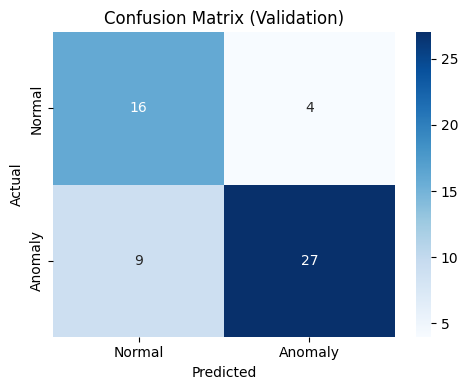

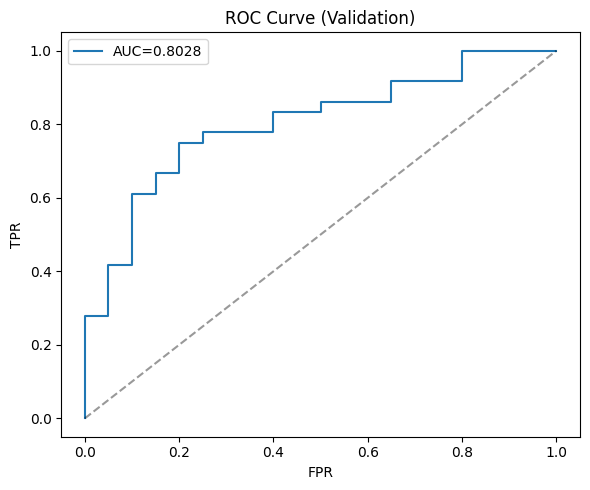

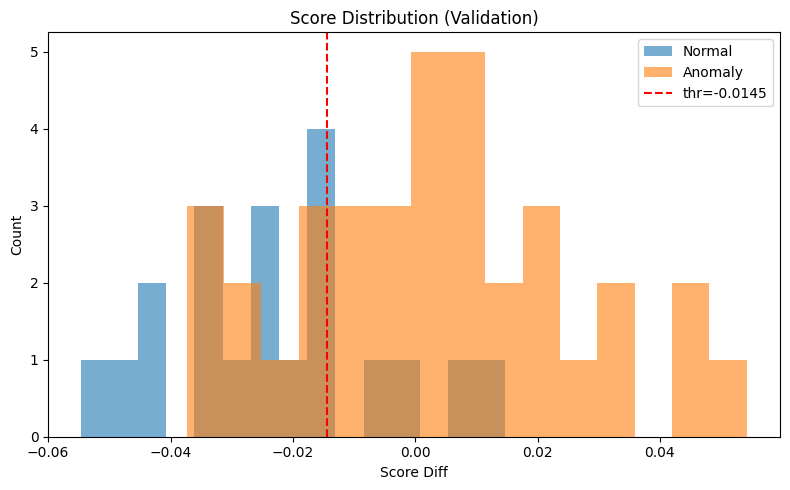


Per-video scores:
                 video_id     true_class  score_diff  predicted_is_anomaly
0           Abuse002_x264          Abuse   -0.037354                 False
1           Abuse008_x264          Abuse    0.034424                  True
2           Abuse043_x264          Abuse    0.030151                  True
3          Arrest009_x264         Arrest   -0.034424                 False
4          Arrest011_x264         Arrest    0.042358                  True
5          Arrest040_x264         Arrest   -0.028809                 False
6         Assault002_x264        Assault    0.000000                  True
7         Assault003_x264        Assault    0.022217                  True
8         Assault007_x264        Assault    0.009766                  True
9        Burglary004_x264       Burglary   -0.010864                  True
10       Burglary084_x264       Burglary    0.047363                  True
11       Burglary090_x264       Burglary   -0.016968                 False
12    

In [10]:
# Confusion Matrix
cm = confusion_matrix(y_true_bool, y_pred_bool)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Anomaly'],
            yticklabels=['Normal', 'Anomaly'])
plt.xlabel("Predicted"); plt.ylabel("Actual")
plt.title("Confusion Matrix (Validation)")
plt.tight_layout()
plt.savefig(f"{PROJECT_ROOT}/outputs/val_confusion_matrix.png", dpi=150)
plt.show()

# ROC Curve
fpr, tpr, _ = roc_curve(y_true_bool, scores)
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"AUC={roc_auc:.4f}")
plt.plot([0, 1], [0, 1], "k--", alpha=.4)
plt.xlabel("FPR"); plt.ylabel("TPR")
plt.title("ROC Curve (Validation)"); plt.legend()
plt.tight_layout()
plt.savefig(f"{PROJECT_ROOT}/outputs/val_roc_curve.png", dpi=150)
plt.show()

# Score Distribution
plt.figure(figsize=(8, 5))
plt.hist(video_df[~video_df["is_anomaly"]]["score_diff"], bins=15, alpha=0.6, label="Normal")
plt.hist(video_df[ video_df["is_anomaly"]]["score_diff"], bins=15, alpha=0.6, label="Anomaly")
plt.axvline(best_threshold, linestyle="--", color="red", label=f"thr={best_threshold:.4f}")
plt.xlabel("Score Diff"); plt.ylabel("Count")
plt.title("Score Distribution (Validation)"); plt.legend()
plt.tight_layout()
plt.savefig(f"{PROJECT_ROOT}/outputs/val_score_dist.png", dpi=150)
plt.show()

print("\nPer-video scores:")
print(video_df[["video_id", "true_class", "score_diff", "predicted_is_anomaly"]].to_string())

## Save Val Artifacts

In [11]:
with open(f"{PROJECT_ROOT}/artifacts/threshold.json", "w") as f:
    json.dump({
        "dataset_mode": DATASET_MODE,
        "threshold"   : float(best_threshold),
        "topk_ratio"  : TOPK_RATIO,
        "metrics": {
            "accuracy"        : float(accuracy),
            "balanced_accuracy": float(balanced_acc),
            "precision"       : float(precision),
            "recall"          : float(recall),
            "specificity"     : float(specificity),
            "f1"              : float(f1),
            "roc_auc"         : float(roc_auc),
            "tp": int(tp), "tn": int(tn),
            "fp": int(fp), "fn": int(fn),
        }
    }, f, indent=4)

video_df.to_csv(f"{PROJECT_ROOT}/outputs/val_video_predictions.csv", index=False)
results_df.to_csv(f"{PROJECT_ROOT}/outputs/val_segment_predictions.csv", index=False)

print("✅  Artifacts saved:")
print(f"    {PROJECT_ROOT}/artifacts/threshold.json")
print(f"    {PROJECT_ROOT}/outputs/val_video_predictions.csv")

✅  Artifacts saved:
    /home/yasemin/video-anomaly-clip/artifacts/threshold.json
    /home/yasemin/video-anomaly-clip/outputs/val_video_predictions.csv


## Segment-Level Inference (Test)

In [12]:
test_results = []
test_errors  = []

print("\nRunning segment-level inference (test)...\n")

for _, row in tqdm(test_df.iterrows(), total=len(test_df)):
    full_path  = Path(row["path"])
    true_class = row["class"]
    video_id   = row["video_id"]

    try:
        pred = clip_model.predict_segment(str(full_path))
        test_results.append({
            "video_id"    : video_id,
            "segment_path": str(full_path),
            "true_class"  : true_class,
            "anomaly_sim" : pred["anomaly_sim"],
            "normal_sim"  : pred["normal_sim"],
            "score"       : pred["score"],
        })
    except Exception as e:
        test_errors.append({"segment": str(full_path), "error": repr(e)})
        print(f"\nERROR: {full_path} -> {repr(e)}")

test_results_df = pd.DataFrame(test_results)
print(f"\nInference done. Success: {len(test_results_df)} | Errors: {len(test_errors)}")
print(test_results_df["true_class"].value_counts())


Running segment-level inference (test)...



100%|█████████████████████████████████████████████████████████████| 1102/1102 [06:49<00:00,  2.69it/s]


Inference done. Success: 1102 | Errors: 0
true_class
NormalVideos     414
Shoplifting      111
Arrest            99
Stealing          81
Abuse             72
Burglary          57
Fighting          47
RoadAccidents     44
Explosion         41
Assault           37
Robbery           34
Shooting          33
Vandalism         32
Name: count, dtype: int64


TEST METRICS
Accuracy         : 0.7143
Balanced Accuracy: 0.6889
Precision        : 0.7778
Recall           : 0.7778
Specificity      : 0.6000
F1               : 0.7778
ROC-AUC          : 0.7431
TP=28  TN=12  FP=8  FN=8


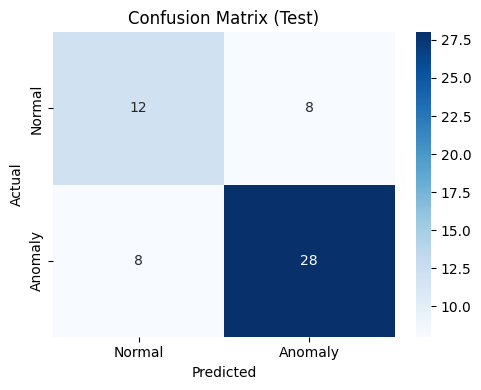

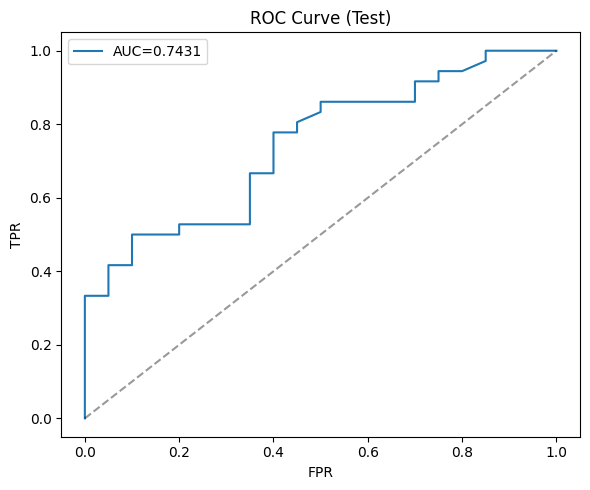


Per-video scores:
                 video_id     true_class  score_diff  predicted_is_anomaly
0           Abuse015_x264          Abuse    0.005859                  True
1           Abuse016_x264          Abuse   -0.000244                  True
2           Abuse018_x264          Abuse    0.030029                  True
3          Arrest008_x264         Arrest   -0.028320                 False
4          Arrest032_x264         Arrest    0.011963                  True
5          Arrest043_x264         Arrest   -0.012451                  True
6         Assault017_x264        Assault    0.013062                  True
7         Assault018_x264        Assault    0.034180                  True
8         Assault037_x264        Assault    0.003906                  True
9        Burglary031_x264       Burglary    0.012207                  True
10       Burglary082_x264       Burglary   -0.031128                 False
11       Burglary097_x264       Burglary    0.025635                  True
12    

In [13]:
test_video_df = aggregate_video_scores(test_results_df)

# Apply ratio and threshold from val calibration
test_video_df["topk_anomaly"] = test_video_df["max_anomaly_sim"].apply(topk_mean)
test_video_df["topk_normal"]  = test_video_df["max_normal_sim"].apply(topk_mean)
test_video_df["score_diff"]   = test_video_df["topk_anomaly"] - test_video_df["topk_normal"]

test_scores = test_video_df["score_diff"]
test_y_true = (test_video_df["true_class"] != "NormalVideos").astype(int).values
test_y_pred = (test_scores > best_threshold).astype(int).values

test_video_df["is_anomaly"]           = test_y_true.astype(bool)
test_video_df["predicted_is_anomaly"] = test_y_pred.astype(bool)

accuracy     = accuracy_score(test_y_true, test_y_pred)
precision    = precision_score(test_y_true, test_y_pred, zero_division=0)
recall       = recall_score(test_y_true, test_y_pred, zero_division=0)
f1           = f1_score(test_y_true, test_y_pred, zero_division=0)
roc_auc      = roc_auc_score(test_y_true, test_scores)
tn, fp, fn, tp = confusion_matrix(test_y_true, test_y_pred).ravel()
specificity  = tn / (tn + fp + 1e-8)
balanced_acc = (recall + specificity) / 2

print("=" * 50)
print("TEST METRICS")
print("=" * 50)
print(f"Accuracy         : {accuracy:.4f}")
print(f"Balanced Accuracy: {balanced_acc:.4f}")
print(f"Precision        : {precision:.4f}")
print(f"Recall           : {recall:.4f}")
print(f"Specificity      : {specificity:.4f}")
print(f"F1               : {f1:.4f}")
print(f"ROC-AUC          : {roc_auc:.4f}")
print(f"TP={tp}  TN={tn}  FP={fp}  FN={fn}")

# Confusion Matrix
cm = confusion_matrix(test_y_true, test_y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Anomaly'],
            yticklabels=['Normal', 'Anomaly'])
plt.xlabel("Predicted"); plt.ylabel("Actual")
plt.title("Confusion Matrix (Test)")
plt.tight_layout()
plt.savefig(f"{PROJECT_ROOT}/outputs/test_confusion_matrix.png", dpi=150)
plt.show()

# ROC Curve
fpr, tpr, _ = roc_curve(test_y_true, test_scores)
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"AUC={roc_auc:.4f}")
plt.plot([0, 1], [0, 1], "k--", alpha=.4)
plt.xlabel("FPR"); plt.ylabel("TPR")
plt.title("ROC Curve (Test)"); plt.legend()
plt.tight_layout()
plt.savefig(f"{PROJECT_ROOT}/outputs/test_roc_curve.png", dpi=150)
plt.show()

print("\nPer-video scores:")
print(test_video_df[["video_id", "true_class", "score_diff", "predicted_is_anomaly"]].to_string())

## Save Test Artifacts

In [14]:
test_video_df.to_csv(f"{PROJECT_ROOT}/outputs/test_video_predictions.csv", index=False)
test_results_df.to_csv(f"{PROJECT_ROOT}/outputs/test_segment_predictions.csv", index=False)

print("✅  Test artifacts saved:")
print(f"    {PROJECT_ROOT}/outputs/test_video_predictions.csv")
print(f"    {PROJECT_ROOT}/outputs/test_segment_predictions.csv")

✅  Test artifacts saved:
    /home/yasemin/video-anomaly-clip/outputs/test_video_predictions.csv
    /home/yasemin/video-anomaly-clip/outputs/test_segment_predictions.csv
